In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
kagglehub.dataset_download('phileinsophos/predict-loan-amount-data')

/kaggle/input/datasets/phileinsophos/predict-loan-amount-data/train.csv
/kaggle/input/datasets/phileinsophos/predict-loan-amount-data/test.csv


'/kaggle/input/datasets/phileinsophos/predict-loan-amount-data'

# Cell 1 — Imports

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings("ignore")

from IPython.display import display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_validate, validation_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'savefig.dpi': 600,
})

sns.set(style="whitegrid")

def set_plot_style():
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 12,
        'axes.labelweight': 'bold',
        'axes.titleweight': 'bold',
        'axes.labelsize': 13,
        'axes.titlesize': 14,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'savefig.dpi': 600,
    })

def save_current_plot(name, folder="figures", close=False):
    os.makedirs(folder, exist_ok=True)
    safe_name = re.sub(r'[^A-Za-z0-9_\-]+', '_', str(name)).strip('_')
    fig = plt.gcf()
    path = os.path.join(folder, f"{safe_name}.eps")
    fig.savefig(path, format="eps", dpi=600, bbox_inches="tight")
    print(f"Saved: {path}")
    if close:
        plt.close(fig)
    return path

# Load dataset
csv_path = "/kaggle/input/datasets/phileinsophos/predict-loan-amount-data/train.csv"   # change this if your file name is different
df = pd.read_csv(csv_path)

# Cell 2 — Load data

In [3]:
TARGET_COL = "loan_amount_sanctioned"   # change only if your column name is different
if TARGET_COL not in df.columns:
    TARGET_COL = df.columns[-1]

df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

X = df.drop(columns=[TARGET_COL])
ID_COLS = ["Customer ID", "Name", "Property ID"]
X = X.drop(columns=[c for c in ID_COLS if c in X.columns])
y = df[TARGET_COL]

print(df.shape)
print(df.head())

(29660, 24)
  Customer ID               Name Gender  Age  Income (USD) Income Stability  \
0     C-36995   Frederica Shealy      F   56       1933.05              Low   
1     C-33999  America Calderone      M   32       4952.91              Low   
2      C-3770      Rosetta Verne      F   65        988.19             High   
3     C-26480         Zoe Chitty      F   65           NaN             High   
4     C-23459       Afton Venema      F   31       2614.77              Low   

  Profession     Type of Employment    Location  Loan Amount Request (USD)  \
0    Working            Sales staff  Semi-Urban                   72809.58   
1    Working                    NaN  Semi-Urban                   46837.47   
2  Pensioner                    NaN  Semi-Urban                   45593.04   
3  Pensioner                    NaN       Rural                   80057.92   
4    Working  High skill tech staff  Semi-Urban                  113858.89   

   ...  Credit Score No. of Defaults Has Act

# Cell 3 — EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29660 entries, 0 to 29659
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  29660 non-null  object 
 1   Name                         29660 non-null  object 
 2   Gender                       29608 non-null  object 
 3   Age                          29660 non-null  int64  
 4   Income (USD)                 25167 non-null  float64
 5   Income Stability             28002 non-null  object 
 6   Profession                   29660 non-null  object 
 7   Type of Employment           22472 non-null  object 
 8   Location                     29660 non-null  object 
 9   Loan Amount Request (USD)    29660 non-null  float64
 10  Current Loan Expenses (USD)  29493 non-null  float64
 11  Expense Type 1               29660 non-null  object 
 12  Expense Type 2               29660 non-null  object 
 13  Dependents      

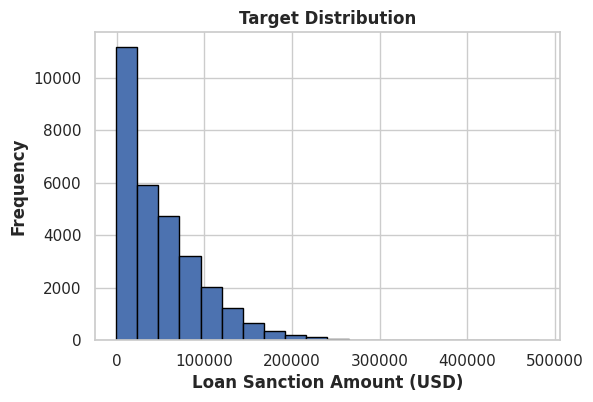

Saved: figures/Age_vs_target.eps


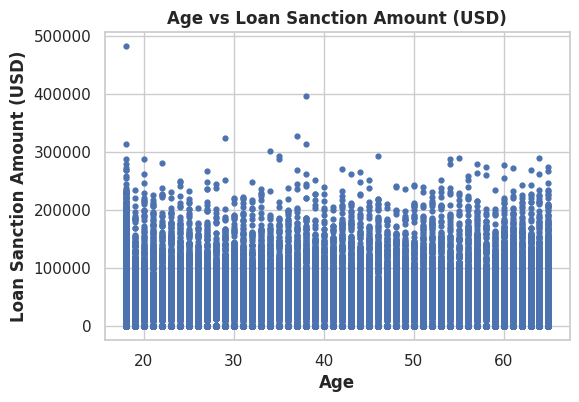

Saved: figures/Income_USD__vs_target.eps


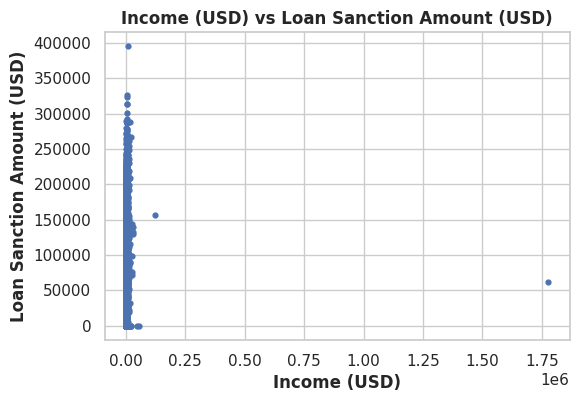

Saved: figures/Loan_Amount_Request_USD__vs_target.eps


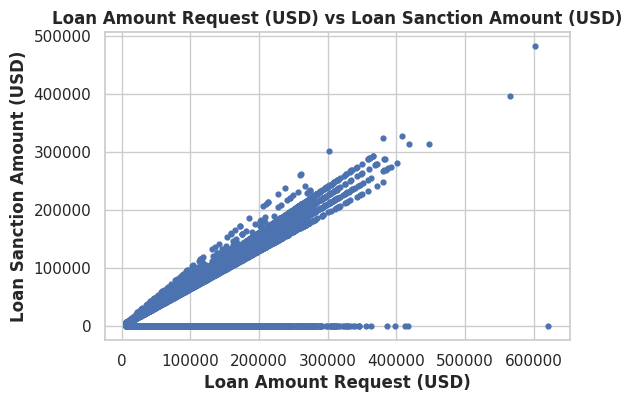

In [4]:
print(df.info())
print(df.isnull().sum())

plt.figure(figsize=(6, 4))
plt.hist(y, bins=20, edgecolor="black")
plt.title("Target Distribution")
plt.xlabel(TARGET_COL)
plt.ylabel("Frequency")
save_current_plot("target_distribution")
plt.show()

num_preview = X.select_dtypes(include=np.number).columns[:3]
for col in num_preview:
    plt.figure(figsize=(6, 4))
    plt.scatter(X[col], y, s=12)
    plt.title(f"{col} vs {TARGET_COL}")
    plt.xlabel(col)
    plt.ylabel(TARGET_COL)
    save_current_plot(f"{col}_vs_target")
    plt.show()

In [5]:
# Feature distribution plots (numeric + categorical)
num_cols_all = X.select_dtypes(include=np.number).columns
cat_cols_all = X.select_dtypes(exclude=np.number).columns

for col in num_cols_all:
    plt.figure(figsize=(6, 4))
    plt.hist(X[col].dropna(), bins=30, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    save_current_plot(f"dist_{col}", close=True)
    plt.show()

for col in cat_cols_all:
    plt.figure(figsize=(6, 4))
    X[col].value_counts(dropna=False).plot(kind="bar", edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    save_current_plot(f"dist_{col}", close=True)
    plt.show()

Saved: figures/dist_Age.eps
Saved: figures/dist_Income_USD.eps
Saved: figures/dist_Loan_Amount_Request_USD.eps
Saved: figures/dist_Current_Loan_Expenses_USD.eps
Saved: figures/dist_Dependents.eps
Saved: figures/dist_Credit_Score.eps
Saved: figures/dist_No_of_Defaults.eps
Saved: figures/dist_Property_Age.eps
Saved: figures/dist_Property_Type.eps
Saved: figures/dist_Co-Applicant.eps
Saved: figures/dist_Property_Price.eps
Saved: figures/dist_Gender.eps
Saved: figures/dist_Income_Stability.eps
Saved: figures/dist_Profession.eps
Saved: figures/dist_Type_of_Employment.eps
Saved: figures/dist_Location.eps
Saved: figures/dist_Expense_Type_1.eps
Saved: figures/dist_Expense_Type_2.eps
Saved: figures/dist_Has_Active_Credit_Card.eps
Saved: figures/dist_Property_Location.eps


# Cell 4 — Train-test split and preprocessing

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(exclude=np.number).columns.tolist()

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

# Cell 5 — Metric and CV helper functions

In [7]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_scores(model):
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "mse": "neg_mean_squared_error",
            "r2": "r2"
        },
        return_train_score=True
    )
    return {
        "Train MAE": -scores["train_mae"].mean(),
        "Val MAE": -scores["test_mae"].mean(),
        "Train MSE": -scores["train_mse"].mean(),
        "Val MSE": -scores["test_mse"].mean(),
        "Train RMSE": np.sqrt(-scores["train_mse"].mean()),
        "Val RMSE": np.sqrt(-scores["test_mse"].mean()),
        "Train R2": scores["train_r2"].mean(),
        "Val R2": scores["test_r2"].mean()
    }

# Cell 6 — Linear Regression

In [8]:
linear_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

start = time.time()

linear_model.fit(X_train, y_train)

linear_time = time.time() - start

linear_cv = cv_scores(linear_model)

linear_pred = linear_model.predict(X_test)

linear_test = regression_metrics(y_test, linear_pred)

print("Linear CV:", linear_cv)
print("Linear Training Time:", linear_time)
print("Linear Test:", linear_test)

Linear CV: {'Train MAE': np.float64(21432.426564108297), 'Val MAE': np.float64(21508.85111899685), 'Train MSE': np.float64(948798128.9525855), 'Val MSE': np.float64(984792431.8626206), 'Train RMSE': np.float64(30802.56692148538), 'Val RMSE': np.float64(31381.402643327157), 'Train R2': np.float64(0.5943298007125686), 'Val R2': np.float64(0.5778542814524861)}
Linear Training Time: 0.24301552772521973
Linear Test: {'MAE': 21589.1233250567, 'MSE': 1018934379.7356939, 'RMSE': np.float64(31920.75155342828), 'R2': 0.5510856453401336}


# Cell 7 — Ridge Regression

In [9]:
ridge_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", Ridge())
])

ridge_grid = GridSearchCV(
    ridge_model,
    {"model__alpha": [0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring="r2"
)

start = time.time()
ridge_grid.fit(X_train, y_train)
ridge_time = time.time() - start

best_ridge = ridge_grid.best_estimator_
ridge_cv = cv_scores(best_ridge)
ridge_pred = best_ridge.predict(X_test)
ridge_test = regression_metrics(y_test, ridge_pred)

print("Ridge Best Params:", ridge_grid.best_params_)
print("Ridge Best CV R2:", ridge_grid.best_score_)
print("Ridge Training Time:", ridge_time)
print("Ridge CV:", ridge_cv)
print("Ridge Test:", ridge_test)

Ridge Best Params: {'model__alpha': 100}
Ridge Best CV R2: 0.5689332481082944
Ridge Training Time: 4.941983461380005
Ridge CV: {'Train MAE': np.float64(21460.10652575267), 'Val MAE': np.float64(21525.523694489548), 'Train MSE': np.float64(949793797.5473017), 'Val MSE': np.float64(983086578.8626387), 'Train RMSE': np.float64(30818.72478781855), 'Val RMSE': np.float64(31354.211501210466), 'Train R2': np.float64(0.593903877273452), 'Val R2': np.float64(0.5786192019576417)}
Ridge Test: {'MAE': 21581.576016876432, 'MSE': 1017251114.7525527, 'RMSE': np.float64(31894.374343331343), 'R2': 0.5518272454163078}


# Cell 8 — Lasso Regression

In [10]:
lasso_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", Lasso(max_iter=3000, tol=1e-3))
])

lasso_grid = GridSearchCV(
    lasso_model,
    {"model__alpha": [0.001, 0.01, 0.1, 1, 10]},   # was [0.01, 0.1, 1]
    cv=5,                                            # was cv=3
    scoring="r2",
    n_jobs=-1
)

start = time.time()

lasso_grid.fit(X_train, y_train)

lasso_time = time.time() - start

best_lasso = lasso_grid.best_estimator_

lasso_cv = cv_scores(best_lasso)

lasso_pred = best_lasso.predict(X_test)

lasso_test = regression_metrics(y_test, lasso_pred)

print("Lasso Best Params:", lasso_grid.best_params_)
print("Lasso Best CV R2:", lasso_grid.best_score_)
print("Lasso Training Time:", lasso_time)
print("Lasso CV:", lasso_cv)
print("Lasso Test:", lasso_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.673e+11, tolerance: 4.402e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.923e+12, tolerance: 4.471e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.036e+12, tolerance: 4.482e

Lasso Best Params: {'model__alpha': 10}
Lasso Best CV R2: 0.5684834771436531
Lasso Training Time: 44.30174899101257
Lasso CV: {'Train MAE': np.float64(21433.567454423057), 'Val MAE': np.float64(21498.3892069517), 'Train MSE': np.float64(949415074.5155599), 'Val MSE': np.float64(983475021.8718704), 'Train RMSE': np.float64(30812.57980947976), 'Val RMSE': np.float64(31360.405320592883), 'Train R2': np.float64(0.5940656695132377), 'Val R2': np.float64(0.5784388831557926)}
Lasso Test: {'MAE': 21564.129729153276, 'MSE': 1017766125.4787517, 'RMSE': np.float64(31902.44701396355), 'R2': 0.5516003459099288}


# Cell 9 — Elastic Net Regression

In [11]:
enet_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", ElasticNet(max_iter=10000, random_state=42))
])

enet_grid = GridSearchCV(
    enet_model,
    {
        "model__alpha": [0.01, 0.1, 1, 10],
        "model__l1_ratio": [0.2, 0.5, 0.8]
    },
    cv=5,
    scoring="r2"
)

start = time.time()
enet_grid.fit(X_train, y_train)
enet_time = time.time() - start

best_enet = enet_grid.best_estimator_
enet_cv = cv_scores(best_enet)
enet_pred = best_enet.predict(X_test)
enet_test = regression_metrics(y_test, enet_pred)

print("Elastic Net Best Params:", enet_grid.best_params_)
print("Elastic Net Best CV R2:", enet_grid.best_score_)
print("Elastic Net Training Time:", enet_time)
print("Elastic Net CV:", enet_cv)
print("Elastic Net Test:", enet_test)

Elastic Net Best Params: {'model__alpha': 0.1, 'model__l1_ratio': 0.2}
Elastic Net Best CV R2: 0.5736498414979236
Elastic Net Training Time: 25.13603901863098
Elastic Net CV: {'Train MAE': np.float64(21797.850854805492), 'Val MAE': np.float64(21842.80822267289), 'Train MSE': np.float64(966786672.8730682), 'Val MSE': np.float64(981372938.3663261), 'Train RMSE': np.float64(31093.19335277527), 'Val RMSE': np.float64(31326.872463850043), 'Train R2': np.float64(0.5866385803560488), 'Val R2': np.float64(0.579672402666058)}
Elastic Net Test: {'MAE': 21850.240107155358, 'MSE': 1021298577.627079, 'RMSE': np.float64(31957.762400191274), 'R2': 0.5500440450253277}


# Cell 10 — Performance tables

In [12]:
cv_table = pd.DataFrame([
    ["Linear Regression", linear_cv["Val MAE"], linear_cv["Val MSE"], linear_cv["Val RMSE"], linear_cv["Val R2"]],
    ["Ridge Regression", ridge_cv["Val MAE"], ridge_cv["Val MSE"], ridge_cv["Val RMSE"], ridge_cv["Val R2"]],
    ["Lasso Regression", lasso_cv["Val MAE"], lasso_cv["Val MSE"], lasso_cv["Val RMSE"], lasso_cv["Val R2"]],
    ["Elastic Net Regression", enet_cv["Val MAE"], enet_cv["Val MSE"], enet_cv["Val RMSE"], enet_cv["Val R2"]],
], columns=["Model", "MAE", "MSE", "RMSE", "R2"])

test_table = pd.DataFrame([
    ["Linear Regression", linear_test["MAE"], linear_test["MSE"], linear_test["RMSE"], linear_test["R2"], linear_time],
    ["Ridge Regression", ridge_test["MAE"], ridge_test["MSE"], ridge_test["RMSE"], ridge_test["R2"], ridge_time],
    ["Lasso Regression", lasso_test["MAE"], lasso_test["MSE"], lasso_test["RMSE"], lasso_test["R2"], lasso_time],
    ["Elastic Net Regression", enet_test["MAE"], enet_test["MSE"], enet_test["RMSE"], enet_test["R2"], enet_time],
], columns=["Model", "MAE", "MSE", "RMSE", "R2", "Training Time"])

tuning_summary = pd.DataFrame([
    ["Ridge Regression", ridge_grid.best_params_, ridge_grid.best_score_],
    ["Lasso Regression", lasso_grid.best_params_, lasso_grid.best_score_],
    ["Elastic Net Regression", enet_grid.best_params_, enet_grid.best_score_]
], columns=["Model", "Best Parameters", "Best CV R2"])

print("Cross-Validation Performance")
print(cv_table)

print("\nTest Set Performance")
print(test_table)

print("\nHyperparameter Tuning Summary")
print(tuning_summary)

Cross-Validation Performance
                    Model           MAE           MSE          RMSE        R2
0       Linear Regression  21508.851119  9.847924e+08  31381.402643  0.577854
1        Ridge Regression  21525.523694  9.830866e+08  31354.211501  0.578619
2        Lasso Regression  21498.389207  9.834750e+08  31360.405321  0.578439
3  Elastic Net Regression  21842.808223  9.813729e+08  31326.872464  0.579672

Test Set Performance
                    Model           MAE           MSE          RMSE        R2  \
0       Linear Regression  21589.123325  1.018934e+09  31920.751553  0.551086   
1        Ridge Regression  21581.576017  1.017251e+09  31894.374343  0.551827   
2        Lasso Regression  21564.129729  1.017766e+09  31902.447014  0.551600   
3  Elastic Net Regression  21850.240107  1.021299e+09  31957.762400  0.550044   

   Training Time  
0       0.243016  
1       4.941983  
2      44.301749  
3      25.136039  

Hyperparameter Tuning Summary
                    Model  

# Cell 11 — Predicted vs actual and residual plot

Best model: Ridge Regression
Saved: figures/predicted_vs_actual.eps


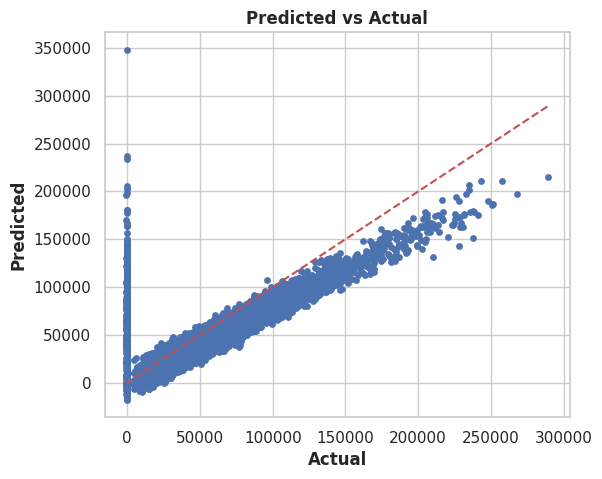

Saved: figures/residual_plot.eps


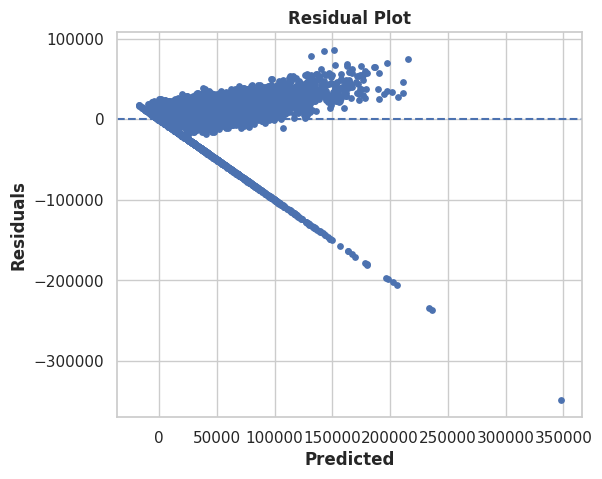

In [13]:
best_model_name = test_table.loc[test_table["R2"].idxmax(), "Model"]
print("Best model:", best_model_name)

model_map = {
    "Linear Regression": linear_model,
    "Ridge Regression": best_ridge,
    "Lasso Regression": best_lasso,
    "Elastic Net Regression": best_enet
}

pred_map = {
    "Linear Regression": linear_pred,
    "Ridge Regression": ridge_pred,
    "Lasso Regression": lasso_pred,
    "Elastic Net Regression": enet_pred
}

best_pred = pred_map[best_model_name]

plt.figure(figsize=(6, 5))
plt.scatter(y_test, best_pred, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
save_current_plot("predicted_vs_actual")
plt.show()

residuals = y_test - best_pred
plt.figure(figsize=(6, 5))
plt.scatter(best_pred, residuals, s=15)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
save_current_plot("residual_plot")
plt.show()

# Cell 12 — Training error vs validation error plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/training_vs_validation_error.eps


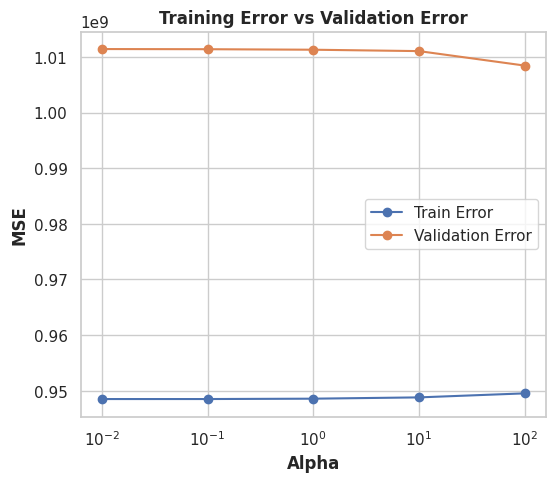

In [14]:
alpha_range = [0.01, 0.1, 1, 10, 100]

train_scores, val_scores = validation_curve(
    ridge_model,
    X_train,
    y_train,
    param_name="model__alpha",
    param_range=alpha_range,
    cv=5,
    scoring="neg_mean_squared_error"
)

plt.figure(figsize=(6, 5))
plt.plot(alpha_range, -train_scores.mean(axis=1), marker="o", label="Train Error")
plt.plot(alpha_range, -val_scores.mean(axis=1), marker="o", label="Validation Error")
plt.xscale("log")
plt.title("Training Error vs Validation Error")
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.legend()
save_current_plot("training_vs_validation_error")
plt.show()

# Cell 13 — Coefficient comparison bar plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/coefficient_comparison.eps


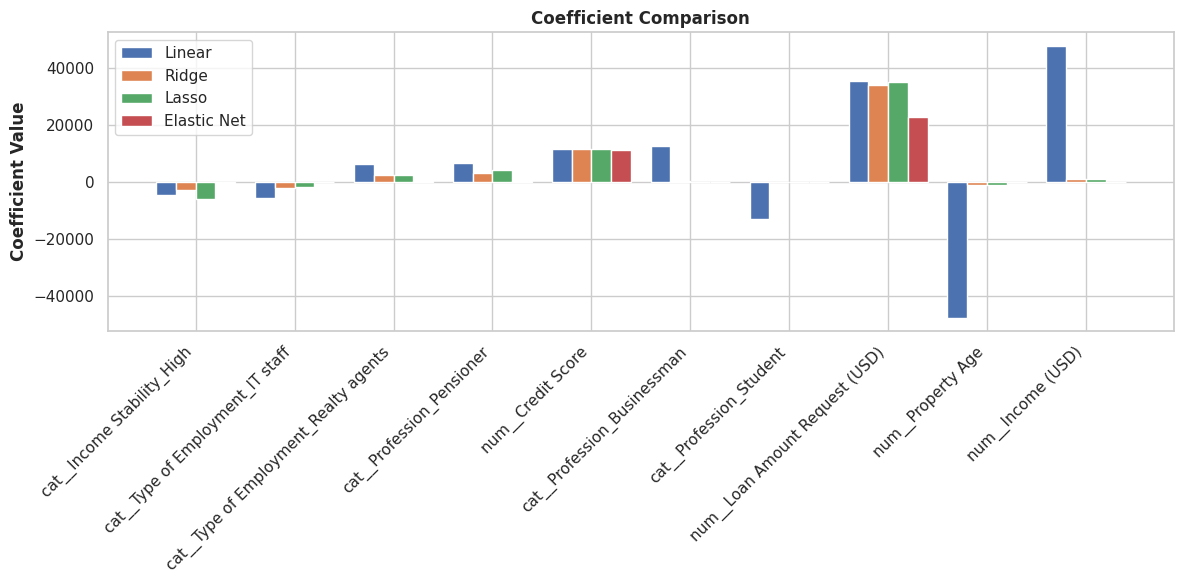

In [15]:
feature_names = linear_model.named_steps["preprocess"].get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Linear": linear_model.named_steps["model"].coef_,
    "Ridge": best_ridge.named_steps["model"].coef_,
    "Lasso": best_lasso.named_steps["model"].coef_,
    "Elastic Net": best_enet.named_steps["model"].coef_
})

top_n = 10
top_idx = np.argsort(np.abs(coef_df["Linear"]))[-top_n:]
top_coef_df = coef_df.iloc[top_idx]

x = np.arange(len(top_coef_df))
w = 0.2

plt.figure(figsize=(12, 6))
plt.bar(x - 1.5*w, top_coef_df["Linear"], width=w, label="Linear")
plt.bar(x - 0.5*w, top_coef_df["Ridge"], width=w, label="Ridge")
plt.bar(x + 0.5*w, top_coef_df["Lasso"], width=w, label="Lasso")
plt.bar(x + 1.5*w, top_coef_df["Elastic Net"], width=w, label="Elastic Net")

plt.xticks(x, top_coef_df["Feature"], rotation=45, ha="right")
plt.title("Coefficient Comparison")
plt.ylabel("Coefficient Value")
plt.legend()
plt.tight_layout()
save_current_plot("coefficient_comparison")
plt.show()

# Cell 14 -  Overfitting / Underfitting Analysis

In [16]:
# ---- Overfitting / Underfitting Analysis ----
models_cv = {
    "Linear Regression": linear_cv,
    "Ridge Regression": ridge_cv,
    "Lasso Regression": lasso_cv,
    "Elastic Net Regression": enet_cv
}

print("Overfitting / Underfitting Analysis")
print("=" * 50)
for name, cv in models_cv.items():
    r2_gap = cv["Train R2"] - cv["Val R2"]
    mse_gap_pct = (cv["Val MSE"] - cv["Train MSE"]) / cv["Train MSE"] * 100
    print(f"\n{name}:")
    print(f"  Train R2 = {cv['Train R2']:.4f}, Val R2 = {cv['Val R2']:.4f}  (gap = {r2_gap:.4f})")
    print(f"  Train MSE = {cv['Train MSE']:.2f}, Val MSE = {cv['Val MSE']:.2f}  (val is {mse_gap_pct:.1f}% higher)")
    if r2_gap > 0.05:
        print("  -> Noticeable train/validation gap: sign of overfitting.")
    elif cv["Train R2"] < 0.5:
        print("  -> Both train and validation R2 are low: sign of underfitting.")
    else:
        print("  -> Train and validation performance are close: generalizing reasonably well.")

print("\nEffect of Regularization Strength")
print("=" * 50)
print(f"Ridge best alpha: {ridge_grid.best_params_['model__alpha']} (CV R2 = {ridge_grid.best_score_:.4f})")
print(f"Lasso best alpha: {lasso_grid.best_params_['model__alpha']} (CV R2 = {lasso_grid.best_score_:.4f})")
print(f"Elastic Net best alpha: {enet_grid.best_params_['model__alpha']}, "
      f"l1_ratio: {enet_grid.best_params_['model__l1_ratio']} (CV R2 = {enet_grid.best_score_:.4f})")

print(f"\nValidation R2 improvement over plain Linear Regression after tuning:")
print(f"  Ridge:       {ridge_cv['Val R2'] - linear_cv['Val R2']:+.4f}")
print(f"  Lasso:       {lasso_cv['Val R2'] - linear_cv['Val R2']:+.4f}")
print(f"  Elastic Net: {enet_cv['Val R2'] - linear_cv['Val R2']:+.4f}")

# ---- Bias-Variance Analysis ----
print("\nBias-Variance Analysis")
print("=" * 50)

coef_std = {
    "Linear": coef_df["Linear"].std(),
    "Ridge": coef_df["Ridge"].std(),
    "Lasso": coef_df["Lasso"].std(),
    "Elastic Net": coef_df["Elastic Net"].std()
}
print("Coefficient standard deviation (proxy for variance/instability):")
for name, std in coef_std.items():
    print(f"  {name}: {std:.4f}")

lasso_zero = (np.abs(coef_df["Lasso"]) < 1e-6).sum()
enet_zero = (np.abs(coef_df["Elastic Net"]) < 1e-6).sum()
total_features = len(coef_df)
print(f"\nLasso zeroed out {lasso_zero}/{total_features} coefficients "
      f"({lasso_zero/total_features*100:.1f}% sparsity) -> automatic feature selection.")
print(f"Elastic Net zeroed out {enet_zero}/{total_features} coefficients "
      f"({enet_zero/total_features*100:.1f}% sparsity).")

print(f"\nLinear Regression: Train R2 = {linear_cv['Train R2']:.4f}, "
      f"Train/Val gap = {linear_cv['Train R2'] - linear_cv['Val R2']:.4f} "
      f"-> {'lower bias' if linear_cv['Train R2'] > 0.6 else 'higher bias'}, "
      f"gap size reflects its variance.")
print(f"Ridge coefficient std ({coef_std['Ridge']:.4f}) vs Linear ({coef_std['Linear']:.4f}): "
      f"{'reduced' if coef_std['Ridge'] < coef_std['Linear'] else 'similar'} variance from shrinkage.")
print(f"Elastic Net (l1_ratio={enet_grid.best_params_['model__l1_ratio']}) blends Ridge's shrinkage "
      f"with Lasso's sparsity.")

Overfitting / Underfitting Analysis

Linear Regression:
  Train R2 = 0.5943, Val R2 = 0.5779  (gap = 0.0165)
  Train MSE = 948798128.95, Val MSE = 984792431.86  (val is 3.8% higher)
  -> Train and validation performance are close: generalizing reasonably well.

Ridge Regression:
  Train R2 = 0.5939, Val R2 = 0.5786  (gap = 0.0153)
  Train MSE = 949793797.55, Val MSE = 983086578.86  (val is 3.5% higher)
  -> Train and validation performance are close: generalizing reasonably well.

Lasso Regression:
  Train R2 = 0.5941, Val R2 = 0.5784  (gap = 0.0156)
  Train MSE = 949415074.52, Val MSE = 983475021.87  (val is 3.6% higher)
  -> Train and validation performance are close: generalizing reasonably well.

Elastic Net Regression:
  Train R2 = 0.5866, Val R2 = 0.5797  (gap = 0.0070)
  Train MSE = 966786672.87, Val MSE = 981372938.37  (val is 1.5% higher)
  -> Train and validation performance are close: generalizing reasonably well.

Effect of Regularization Strength
Ridge best alpha: 100 (CV 

In [17]:
!zip -r output.zip /kaggle/working/figures

  adding: kaggle/working/figures/ (stored 0%)
  adding: kaggle/working/figures/dist_Profession.eps (deflated 66%)
  adding: kaggle/working/figures/dist_Property_Location.eps (deflated 65%)
  adding: kaggle/working/figures/residual_plot.eps (deflated 63%)
  adding: kaggle/working/figures/dist_Gender.eps (deflated 65%)
  adding: kaggle/working/figures/dist_Dependents.eps (deflated 73%)
  adding: kaggle/working/figures/dist_Age.eps (deflated 71%)
  adding: kaggle/working/figures/predicted_vs_actual.eps (deflated 63%)
  adding: kaggle/working/figures/dist_Type_of_Employment.eps (deflated 69%)
  adding: kaggle/working/figures/dist_No_of_Defaults.eps (deflated 72%)
  adding: kaggle/working/figures/dist_Has_Active_Credit_Card.eps (deflated 64%)
  adding: kaggle/working/figures/dist_Property_Price.eps (deflated 72%)
  adding: kaggle/working/figures/dist_Property_Type.eps (deflated 73%)
  adding: kaggle/working/figures/dist_Current_Loan_Expenses_USD.eps (deflated 70%)
  adding: kaggle/working/f